# Semiconductor Quality Control - Logistic Regression Analysis
---
Sequential analysis of semiconductor defects using Logistic Regression, including regularization, polynomial features, and threshold tuning.


# 1. Imports and Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import make_scorer, fbeta_score, recall_score, precision_score, ConfusionMatrixDisplay, accuracy_score
from sklearn.pipeline import Pipeline

# Configuration
RANDOM_STATE = 35
FOLDS = 4
FILE_PATH = 'semiconductor_quality_control.csv'


# 2. Preliminaries
## 2.1 Load Data and Cleaning
Loading the dataset, dropping identifiers, and handling categorical variables.


In [8]:
print(f">>> Loading Data from {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
# to drop identifiers and leakage columns (sourced from log_reg_vanilla.py)
sybau = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Defect', 'Join_Status']
x = df.drop(columns=sybau)
y = df['Defect']
x = pd.get_dummies(x, columns=['Tool_Type'], drop_first=True) 
#tool type was text categorical, so one-hot encoded it, drop first cuz only one is needed to avoid multicollinearity
#Also the data is pretty clean, so decided no missing value imputation or outlier removal needed
print("Data Loading Done. Welcome to TSMC (not sponsored, just roleplaying). Shape : ", x.shape)


>>> Loading Data from semiconductor_quality_control.csv...
Data Loading Done. Welcome to TSMC (not sponsored, just roleplaying). Shape :  (4219, 12)


## 2.2 Train/Test Split and Normalization
Standardizing numerical features.


In [9]:
numerical_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth',
                  'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error',
                  'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
#stratified y to maintain equal split for defects and non-defects

#scaling done to prevent features with larger ranges from dominating those with smaller ranges.
scaler = StandardScaler()
scaler.fit(x_train[numerical_cols])
x_train.loc[:,numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test.loc[:,numerical_cols] = scaler.transform(x_test[numerical_cols])

print('Pre-processing done!')
# i need to figure out how to remove the fucking warning which is marring the output


Pre-processing done!


/var/folders/t5/627dv0pd3j75b82255bt57n40000gn/T/ipykernel_90428/2323208671.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.18953121 -1.58810194  0.03060083 ... -0.56216356 -1.72109395
  1.67970177]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:,numerical_cols] = scaler.transform(x_train[numerical_cols])
/var/folders/t5/627dv0pd3j75b82255bt57n40000gn/T/ipykernel_90428/2323208671.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-6.57157858e-01  2.43388046e-01  1.04513989e+00  1.35292140e+00
 -7.44552608e-01  1.56570861e+00 -5.27965618e-01 -1.10933070e+00
  1.27312619e+00  4.44775949e-01 -1.97385476e-01 -1.18532613e+00
 -3.34177259e-01 -1.09990726e-01  1.59230702e+00  1.36432071e+00
  1.50871204e+00 -1.45510992e+00  2.58587133e-01 -1.28032042e+00
  9.69144450e-01 -1.63187531e-

# 3. Exploratory Analysis
## 3.1 Feature Correlations
Analyzing which features have the strongest relationship with the Defect target.


Feature with highest correlation to Defect: Particle_Count (-0.0284)


/var/folders/t5/627dv0pd3j75b82255bt57n40000gn/T/ipykernel_90428/2502560727.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_pass, data_defect], labels=['Pass (0)', 'Defect (1)'])


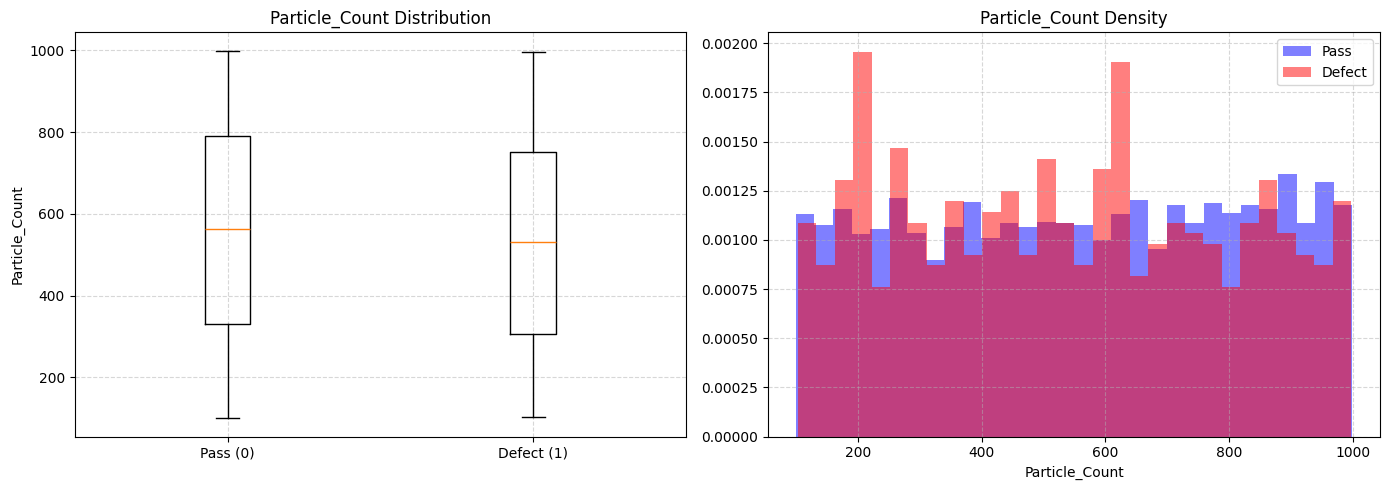

In [10]:
# 1. Find Best Correlated Feature
# Re-attach target temporarily to calculate correlation
df_temp = x.copy()
df_temp['Defect'] = y
correlations = df_temp.corr()['Defect'].drop('Defect')

best_feature = correlations.abs().idxmax()
best_acc = correlations[best_feature]

print(f"Feature with highest correlation to Defect: {best_feature} ({best_acc:.4f})")

# 2. Plot Distribution (Matplotlib only)
plt.figure(figsize=(14, 5))

# Get data for both classes
data_pass = df_temp[df_temp['Defect'] == 0][best_feature]
data_defect = df_temp[df_temp['Defect'] == 1][best_feature]

# Box Plot
plt.subplot(1, 2, 1)
plt.boxplot([data_pass, data_defect], labels=['Pass (0)', 'Defect (1)'])
plt.title(f'{best_feature} Distribution')
plt.ylabel(best_feature)
plt.grid(True, linestyle='--', alpha=0.5)

# Histogram
plt.subplot(1, 2, 2)
plt.hist(data_pass, bins=30, alpha=0.5, label='Pass', density=True, color='blue')
plt.hist(data_defect, bins=30, alpha=0.5, label='Defect', density=True, color='red')
plt.title(f'{best_feature} Density')
plt.xlabel(best_feature)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Baseline Modeling
## 4.1 Vanilla Logistic Regression
Training a standard logistic regression model with class balancing.


In [11]:
# From log_reg_vanilla.py
model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
model.fit(x_train, y_train)
print('Vanilla Model Trained!')


Vanilla Model Trained!


## 4.2 Cross Validation Evaluation
Evaluating the baseline performance using Stratified K-Fold.


In [12]:
# From log_reg_cross_val.py
pipeline = Pipeline([('scaler', StandardScaler()),('classifier', LogisticRegression(class_weight='balanced', C=1.0, max_iter=2000, random_state=1))])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
scoring = ['recall', 'f1', 'accuracy', 'precision']
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"{'Fold':<6} {'Recall':<10} {'Precision':<10} {'F1':<10} {'Accuracy':<10}")
print("-" * 50)

for i in range(4):
    print(f"{i+1:<6} {scores['test_recall'][i]:<10.4f} {scores['test_precision'][i]:<10.4f} {scores['test_f1'][i]:<10.4f} {scores['test_accuracy'][i]:<10.4f}")

print("-" * 50)
print(f"Mean Recall: {np.mean(scores['test_recall']):.4f}")


Fold   Recall     Precision  F1         Accuracy  
--------------------------------------------------
1      0.4481     0.1364     0.2091     0.5052    
2      0.4805     0.1520     0.2309     0.5327    
3      0.4258     0.1320     0.2015     0.5043    
4      0.4675     0.1452     0.2215     0.5199    
--------------------------------------------------
Mean Recall: 0.4555


# 5. Regularization
## 5.1 L1 (Lasso) vs L2 (Ridge) Grid Search
Iterating through penalty types and regularization strengths.


In [13]:
# From log_reg_compiled.py
penalties = ['l1', 'l2']
C_values = np.logspace(-4, 4, 10)  # 10 values from 0.0001 to 10000
results = []

# Custom scorer for F2 (Beta=2 emphasizes Recall)
f2_scorer = make_scorer(fbeta_score, beta=2)

print(f"{'Penalty':<10} {'C':<12} {'F2':<10} {'Recall':<12}")
print("-" * 50)

for penalty in penalties:
    for C in C_values:
        # Solver selection based on penalty
        solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
        if penalty == 'l1': solver = 'liblinear' # force liblinear for l1 compatibility
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty=penalty, 
                C=C, 
                solver=solver, 
                class_weight='balanced', 
                max_iter=5000, 
                random_state=RANDOM_STATE
            ))
        ])
        
        cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=RANDOM_STATE)
        
        f2_scores = cross_val_score(pipeline, x, y, cv=cv, scoring=f2_scorer)
        rec_scores = cross_val_score(pipeline, x, y, cv=cv, scoring='recall')
        
        mean_f2 = np.mean(f2_scores)
        mean_rec = np.mean(rec_scores)
        
        results.append({
            'Penalty': penalty,
            'C': C,
            'F2': mean_f2,
            'Recall': mean_rec
        })
        
        print(f"{penalty:<10} {C:<12.5f} {mean_f2:<10.4f} {mean_rec:<12.4f}")

results_df = pd.DataFrame(results)


Penalty    C            F2         Recall      
--------------------------------------------------
l1         0.00010      0.0000     0.0000      
l1         0.00077      0.0000     0.0000      
l1         0.00599      0.0000     0.0000      
l1         0.04642      0.3335     0.4895      
l1         0.35938      0.3259     0.4733      
l1         2.78256      0.3186     0.4587      
l1         21.54435     0.3197     0.4603      
l1         166.81005    0.3197     0.4603      
l1         1291.54967   0.3197     0.4603      
l1         10000.00000  0.3197     0.4603      
l2         0.00010      0.3234     0.4668      
l2         0.00077      0.3249     0.4684      
l2         0.00599      0.3224     0.4652      
l2         0.04642      0.3200     0.4603      
l2         0.35938      0.3198     0.4603      
l2         2.78256      0.3195     0.4603      
l2         21.54435     0.3195     0.4603      
l2         166.81005    0.3195     0.4603      
l2         1291.54967   0.3195     0.

## 5.2 Regularization Visualization
Plotting the impact of C values on Recall and F2 score.


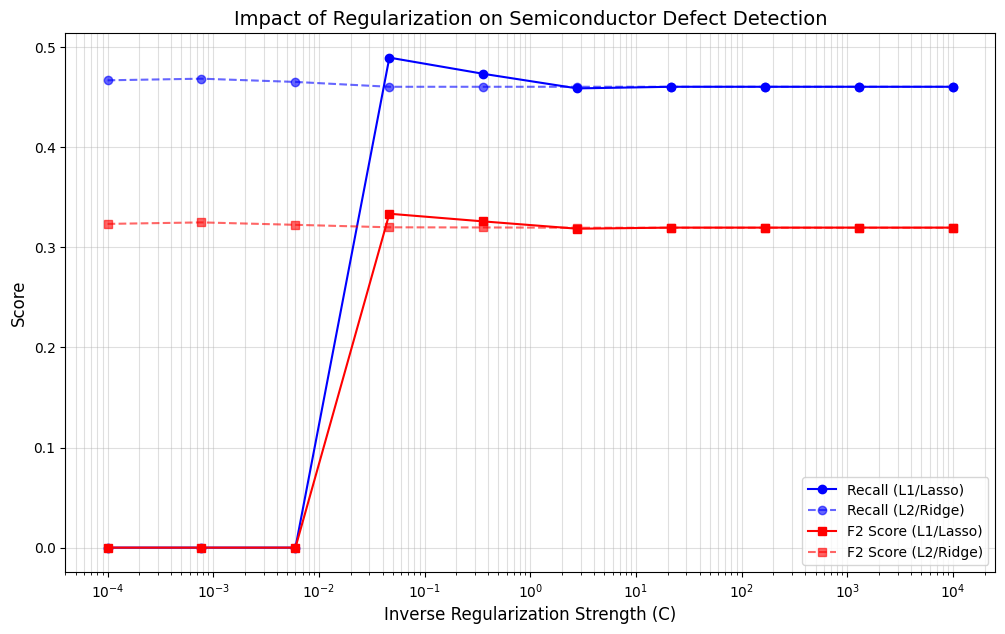

In [14]:
# From log_reg_regularization_var.py
plt.figure(figsize=(12, 7))

df_l1 = results_df[results_df['Penalty'] == 'l1']
df_l2 = results_df[results_df['Penalty'] == 'l2']

# --- Plot Recall ---
plt.plot(df_l1['C'], df_l1['Recall'], label='Recall (L1/Lasso)', 
         color='blue', marker='o', linestyle='-')
plt.plot(df_l2['C'], df_l2['Recall'], label='Recall (L2/Ridge)', 
         color='blue', marker='o', linestyle='--', alpha=0.6)

# --- Plot F2 Score ---
plt.plot(df_l1['C'], df_l1['F2'], label='F2 Score (L1/Lasso)', 
         color='red', marker='s', linestyle='-')
plt.plot(df_l2['C'], df_l2['F2'], label='F2 Score (L2/Ridge)', 
         color='red', marker='s', linestyle='--', alpha=0.6)

plt.xscale('log')
plt.xlabel('Inverse Regularization Strength (C)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Impact of Regularization on Semiconductor Defect Detection', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.show()


Also seeing the effect of regularization change and zeroing out unimportant features

Running Regularization Path...
Best C: 0.0574 | Best F2: 0.3462


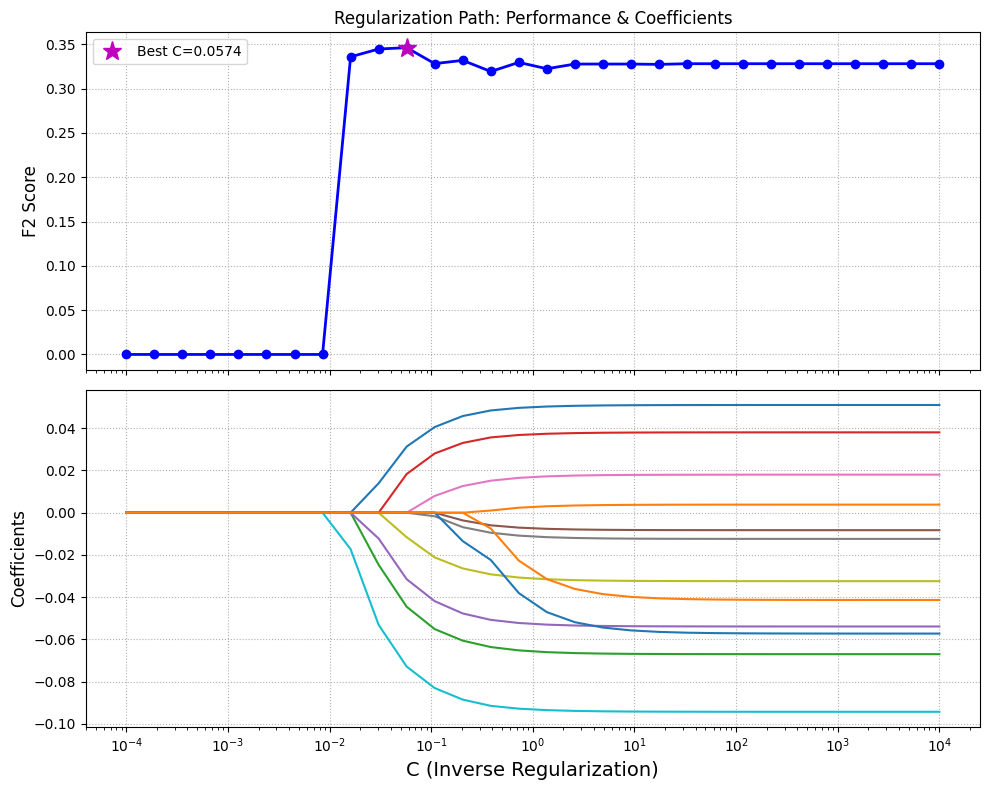

In [15]:
# Define range of C values (Regularization Strength)
Cs = np.logspace(-4, 4, 30)
coefs = []
f2_scores = []

print("Running Regularization Path...")

for C in Cs:
    # Use L1 penalty (Lasso) to match Lab 5's feature selection style
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', class_weight='balanced', random_state=1)
    model.fit(x_train, y_train)
    
    # Store coefficients and score
    coefs.append(model.coef_[0])
    y_pred = model.predict(x_test)
    f2_scores.append(fbeta_score(y_test, y_pred, beta=2))

coefs = np.array(coefs)
f2_scores = np.array(f2_scores)

# Find Best C (cstar)
best_idx = np.argmax(f2_scores)
best_C = Cs[best_idx]
best_f2 = f2_scores[best_idx]
best_coefs = coefs[best_idx]

print(f"Best C: {best_C:.4f} | Best F2: {best_f2:.4f}")

# --- PLOT: Regularization Path ---
fig, ax = plt.subplots(figsize=(10, 8), nrows=2, sharex=True)

# Top Subplot: Performance vs C
ax[0].semilogx(Cs, f2_scores, 'o-', color='b', linewidth=2)
ax[0].semilogx(best_C, best_f2, '*', color='m', markersize=14, label=f'Best C={best_C:.4f}')
ax[0].set_ylabel('F2 Score', fontsize=12)
ax[0].grid(linestyle=':')
ax[0].legend()
ax[0].set_title('Regularization Path: Performance & Coefficients')

# Bottom Subplot: Coefficients vs C
ax[1].semilogx(Cs, coefs)
ax[1].set_xlabel('C (Inverse Regularization)', fontsize=14)
ax[1].set_ylabel('Coefficients', fontsize=12)
ax[1].grid(linestyle=':')

plt.tight_layout()
plt.show()

# 6. Advanced Feature Engineering
## 6.1 Polynomial Features
Expanding the feature space to capture interactions and non-linearities.


In [16]:
# From log_reg_poly_features.py

categorical_cols = [c for c in x.columns if c not in numerical_cols]

# Create poly features on numerical columns only (using original train/test split data)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
x_train_poly = poly.fit_transform(x_train[numerical_cols])
x_test_poly = poly.fit_transform(x_test[numerical_cols])

# Stack with categorical columns
x_train_final = np.hstack([x_train_poly, x_train[categorical_cols].values])
x_test_final = np.hstack([x_test_poly, x_test[categorical_cols].values])

print('Poly Features Created. New Shape:', x_train_final.shape)

# Train model on Poly Features
model_poly = LogisticRegression(class_weight='balanced', C=0.1, random_state=35)
model_poly.fit(x_train_final, y_train)
print('Poly Model Trained!')

y_pred_poly = model_poly.predict_proba(x_test_final)[:,1]


Poly Features Created. New Shape: (3375, 67)
Poly Model Trained!


# 7. Optimization
## 7.1 Threshold Tuning ("Caramel")
Optimizing the decision threshold to maximize F2/Recall.


In [17]:
# From log_reg_with_caramel.py

# Using probabilities from the Poly model (or we could use the Vanilla model)
y_pred = y_pred_poly # Using Poly predictions

best_score = 0
best_thresh = 0.5

print("Tuning Threshold...")
for t in np.arange(0.1,1.0,0.05):
    temp_pred = (y_pred >= t).astype(int)
    # Note: User code switched between f2 and recall. Using Recall as per last user script block.
    recall = recall_score(y_test, temp_pred)
    # print('Threshold:',t, 'Recall: ', recall)
    if recall > best_score: 
        best_score = recall
        best_thresh = t

print(f"Best Threshold: {best_thresh}")
print(f"Best Recall: {best_score}")


Tuning Threshold...
Best Threshold: 0.1
Best Recall: 1.0


## 7.2 Winning Configuration
Final Summary of the best parameters found.


In [18]:
# From log_reg_best.py
best_f2_idx = results_df['F2'].idxmax()
best_rec_idx = results_df['Recall'].idxmax()

print("\n" + "="*50)
print(" WINNING CONFIGURATIONS ")
print("="*50)
print(f"Best F2 Score:   {results_df.loc[best_f2_idx, 'F2']:.4f}")
print(f"  -> Params:     Penalty={results_df.loc[best_f2_idx, 'Penalty']}, C={results_df.loc[best_f2_idx, 'C']:.5f}")
print(f"Best Recall:     {results_df.loc[best_rec_idx, 'Recall']:.4f}")
print(f"  -> Params:     Penalty={results_df.loc[best_rec_idx, 'Penalty']}, C={results_df.loc[best_rec_idx, 'C']:.5f}")



 WINNING CONFIGURATIONS 
Best F2 Score:   0.3335
  -> Params:     Penalty=l1, C=0.04642
Best Recall:     0.4895
  -> Params:     Penalty=l1, C=0.04642
